## 1. Setup Repository and Dependencies

In [29]:

# Clone the repository
!git clone https://github.com/Adr44mo/ML4VM_yolov8n.git
%cd ML4VM_yolov8n
!git checkout feature/reorganized-structure

Cloning into 'ML4VM_yolov8n'...
remote: Enumerating objects: 126, done.
remote: Counting objects: 100% (126/126), done.
remote: Compressing objects: 100% (85/85), done.
remote: Total 126 (delta 42), reused 113 (delta 33), pack-reused 0 (from 0)
Receiving objects: 100% (126/126), 10.74 MiB | 14.43 MiB/s, done.
Resolving deltas: 100% (42/42), done.
/content/ML4VM_yolov8n/ML4VM_yolov8n
Branch 'feature/reorganized-structure' set up to track remote branch 'feature/reorganized-structure' from 'origin'.
Switched to a new branch 'feature/reorganized-structure'


In [2]:
# Install required packages
!pip install -q ultralytics opencv-python pyyaml matplotlib numpy torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 48.7 MB/s eta 0:00:00


In [30]:
%cd ..

/content/ML4VM_yolov8n


In [18]:
# Import necessary libraries
import os
import sys
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from torch.utils.data import DataLoader

# Add project directories to path
sys.path.append('models')
sys.path.append('data')
sys.path.append('configs')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4


## 2. Download and Setup Datasets

### Option A: Download COCO val2017 (small subset)
This will download a small subset of COCO validation images (~1GB)

In [4]:
# Create COCO directory structure
!mkdir -p COCO/images/val2017

# Download COCO val2017 images (this takes a while - ~1GB)
!wget -q http://images.cocodataset.org/zips/val2017.zip
!unzip -q val2017.zip -d COCO/images/
!rm val2017.zip

print("COCO images downloaded!")


COCO images downloaded!


### Option B: Mount Google Drive (if you have COCO already)
Uncomment and modify paths if you have COCO on Google Drive

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
#
# # Create symlink to your COCO dataset on Drive
# !ln -s /content/drive/MyDrive/datasets/COCO ./COCO

## 3. Import Configuration and Model Components

Import all the YOLOv8 components from the reorganized repository structure.  
This model detects all 80 COCO object classes with pose estimation (lying/sitting/standing/other) for all objects.

In [31]:
# Import configuration
from config import (
    ModelConfig, DataConfig, TrainConfig, ValConfig, VisConfig,
    model_config, data_config, train_config, val_config, vis_config,
    print_config
)

# Import model components
from model_components import (
    Conv, Bottleneck, C2f, SPPF, Upsample,
    Backbone, Neck, Head, DFL, MyYolo
)

# Import pose detection components
from head_with_pose import HeadWithPose
from loss_with_pose import ComputeLossWithPose
from ovad_pose_dataset import OVADPoseDataset

print("✓ All imports successful")
print_config()


✓ All imports successful
YOLOv8 Pose Detection Configuration

[MODEL]
  VERSION: n
  NUM_CLASSES: 80
  NUM_POSES: 4
  POSE_CLASSES: ['lying', 'sitting', 'standing', 'other']
  INPUT_SIZE: 640
  DFL_CHANNELS: 16
  STRIDES: [8.0, 16.0, 32.0]
  PRETRAINED_WEIGHTS: /content/ML4VM_yolov8n/models/pretrained/yolov8n.pt
  USE_PRETRAINED: False

[DATA]
  USE_OVAD: True
  OVAD_JSON_PATH: /content/ML4VM_yolov8n/ovad/ovad2000.json
  COCO_IMG_DIR: /content/ML4VM_yolov8n/COCO/images/val2017
  AUGMENT_TRAIN: True
  AUGMENT_VAL: False
  BATCH_SIZE: 8
  NUM_WORKERS: 4
  PIN_MEMORY: True
  SHUFFLE_TRAIN: True
  SHUFFLE_VAL: False
  TRAIN_SPLIT: 0.8
  VAL_SPLIT: 0.2
  RANDOM_SEED: 42
  POSE_ATTRIBUTES: {'lying': 94, 'sitting': 95, 'standing': 96}
  PERSON_CATEGORY_ID: 1

[TRAIN]
  RANDOM_SEED: 42
  NUM_EPOCHS: 10
  WARMUP_EPOCHS: 3
  OPTIMIZER: AdamW
  LEARNING_RATE: 0.001
  WEIGHT_DECAY: 0.0005
  MOMENTUM: 0.937
  SCHEDULER: CosineAnnealingLR
  LR_MIN: 1e-05
  LR_DECAY_EPOCHS: 10
  LR_DECAY_FACTOR: 0.1


### Reload Configuration after external changes

If you modify `config.py` externally and need those changes to be reflected in your Colab session without restarting the runtime, run the cell below. This explicitly reloads the `config` module and then re-imports the configuration variables.

In [32]:
import importlib
import config # Import the config module itself

# Reload the config module
importlib.reload(config)

# Re-import configuration to get updated values
from config import (
    ModelConfig, DataConfig, TrainConfig, ValConfig, VisConfig,
    model_config, data_config, train_config, val_config, vis_config,
    print_config
)

print("✓ Configuration reloaded successfully!")
print_config()

✓ Configuration reloaded successfully!
YOLOv8 Pose Detection Configuration

[MODEL]
  VERSION: n
  NUM_CLASSES: 80
  NUM_POSES: 4
  POSE_CLASSES: ['lying', 'sitting', 'standing', 'other']
  INPUT_SIZE: 640
  DFL_CHANNELS: 16
  STRIDES: [8.0, 16.0, 32.0]
  PRETRAINED_WEIGHTS: /content/ML4VM_yolov8n/models/pretrained/yolov8n.pt
  USE_PRETRAINED: False

[DATA]
  USE_OVAD: True
  OVAD_JSON_PATH: /content/ML4VM_yolov8n/ovad/ovad2000.json
  COCO_IMG_DIR: /content/ML4VM_yolov8n/COCO/images/val2017
  AUGMENT_TRAIN: True
  AUGMENT_VAL: False
  BATCH_SIZE: 8
  NUM_WORKERS: 4
  PIN_MEMORY: True
  SHUFFLE_TRAIN: True
  SHUFFLE_VAL: False
  TRAIN_SPLIT: 0.8
  VAL_SPLIT: 0.2
  RANDOM_SEED: 42
  POSE_ATTRIBUTES: {'lying': 94, 'sitting': 95, 'standing': 96}
  PERSON_CATEGORY_ID: 1

[TRAIN]
  RANDOM_SEED: 42
  NUM_EPOCHS: 50
  WARMUP_EPOCHS: 3
  OPTIMIZER: AdamW
  LEARNING_RATE: 0.001
  WEIGHT_DECAY: 0.0005
  MOMENTUM: 0.937
  SCHEDULER: CosineAnnealingLR
  LR_MIN: 1e-05
  LR_DECAY_EPOCHS: 10
  LR_DECA

## 4. Load Configuration and Dataset

In [33]:
# Set device and random seed
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

torch.manual_seed(train_config.RANDOM_SEED)
np.random.seed(train_config.RANDOM_SEED)

# Create dataset using new simplified loader
print("\nLoading OVAD Pose Dataset...")
ovad_dataset = OVADPoseDataset(
    ovad_json_path=data_config.OVAD_JSON_PATH,
    images_dir=data_config.COCO_IMG_DIR,
    input_size=model_config.INPUT_SIZE,
    augment=data_config.AUGMENT_TRAIN
)

print(f"✓ Dataset loaded successfully!")
print(f"  Number of images: {len(ovad_dataset)}")
print(f"  Pose classes: {ovad_dataset.pose_classes}")

# Create dataloader
pose_loader = DataLoader(
    ovad_dataset,
    batch_size=data_config.BATCH_SIZE,
    shuffle=data_config.SHUFFLE_TRAIN,
    num_workers=data_config.NUM_WORKERS,
    pin_memory=data_config.PIN_MEMORY,
    collate_fn=OVADPoseDataset.collate_fn
)

print(f"  Batch size: {data_config.BATCH_SIZE}")
print(f"  Number of batches: {len(pose_loader)}")


Using device: cuda

Loading OVAD Pose Dataset...
Loading OVAD dataset from /content/ML4VM_yolov8n/ovad/ovad2000.json...
✓ Loaded 2000 images with 14300 annotations
  Categories: 80 unique classes
  Pose distribution: lying=2563, sitting=1136, standing=7799, other=2802
✓ Dataset loaded successfully!
  Number of images: 2000
  Pose classes: ['lying', 'sitting', 'standing', 'other']
  Batch size: 8
  Number of batches: 250


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


## 5. Initialize Model

In [34]:
# Create model with pose detection head
class MyYoloWithPose(nn.Module):
    def __init__(self, version='n'):
        super().__init__()
        self.backbone = Backbone(version=version)
        self.neck = Neck(version=version)
        self.head = HeadWithPose(
            version=version,
            num_classes=model_config.NUM_CLASSES,
            num_poses=model_config.NUM_POSES
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.neck(x[0], x[1], x[2])
        return self.head(list(x))

# Initialize model
model_pose = MyYoloWithPose(version=model_config.VERSION).to(device)
model_pose.head.stride = torch.tensor(model_config.STRIDES)

total_params = sum(p.numel() for p in model_pose.parameters())
print(f"\nModel initialized: {total_params/1e6:.2f}M parameters")
print(f"  - Backbone: {sum(p.numel() for p in model_pose.backbone.parameters())/1e6:.2f}M")
print(f"  - Neck: {sum(p.numel() for p in model_pose.neck.parameters())/1e6:.2f}M")
print(f"  - Head (with pose): {sum(p.numel() for p in model_pose.head.parameters())/1e6:.2f}M")



Model initialized: 3.17M parameters
  - Backbone: 1.27M
  - Neck: 0.99M
  - Head (with pose): 0.91M


## 6. Setup Training

In [35]:
# Setup loss and optimizer
criterion_pose = ComputeLossWithPose(
    model_pose,
    train_config.LOSS_WEIGHTS,
    num_poses=model_config.NUM_POSES
)

optimizer_pose = torch.optim.AdamW(
    model_pose.parameters(),
    lr=train_config.LEARNING_RATE,
    weight_decay=train_config.WEIGHT_DECAY
)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_pose,
    T_max=train_config.NUM_EPOCHS,
    eta_min=train_config.LR_MIN
)

# Mixed precision scaler
scaler = torch.cuda.amp.GradScaler() if train_config.USE_AMP else None

print("Training setup complete!")
print(f"  Optimizer: {train_config.OPTIMIZER} (lr={train_config.LEARNING_RATE})")
print(f"  Loss weights: {train_config.LOSS_WEIGHTS}")
print(f"  Mixed precision: {train_config.USE_AMP}")


Training setup complete!
  Optimizer: AdamW (lr=0.001)
  Loss weights: {'box': 7.5, 'cls': 0.5, 'dfl': 1.5, 'pose': 1.0}
  Mixed precision: True


/tmp/ipython-input-2318059301.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if train_config.USE_AMP else None


## 7. Training Loop

In [36]:
# Training history
history = {
    'epoch': [],
    'total_loss': [],
    'box_loss': [],
    'cls_loss': [],
    'dfl_loss': [],
    'pose_loss': [],
    'lr': []
}

# Create checkpoints directory
os.makedirs('outputs/checkpoints', exist_ok=True)

print(f"Starting training for {train_config.NUM_EPOCHS} epochs...\n")
print("=" * 80)

model_pose.train()
for epoch in range(train_config.NUM_EPOCHS):
    epoch_losses = {'total': 0, 'box': 0, 'cls': 0, 'dfl': 0, 'pose': 0}

    for batch_idx, (images, targets) in enumerate(pose_loader):
        # Move to device
        images = images.float().to(device)
        targets['cls'] = targets['cls'].to(device)
        targets['box'] = targets['box'].to(device)
        targets['idx'] = targets['idx'].to(device)
        targets['pose'] = targets['pose'].to(device)

        # Forward pass with mixed precision
        if train_config.USE_AMP:
            with torch.cuda.amp.autocast():
                outputs = model_pose(images)
                loss_box, loss_cls, loss_dfl, loss_pose = criterion_pose(outputs, targets)
                total_loss = loss_box + loss_cls + loss_dfl + loss_pose
        else:
            outputs = model_pose(images)
            loss_box, loss_cls, loss_dfl, loss_pose = criterion_pose(outputs, targets)
            total_loss = loss_box + loss_cls + loss_dfl + loss_pose

        # Backward pass
        optimizer_pose.zero_grad()
        if train_config.USE_AMP:
            scaler.scale(total_loss).backward()
            scaler.unscale_(optimizer_pose)
            torch.nn.utils.clip_grad_norm_(model_pose.parameters(), train_config.GRAD_CLIP)
            scaler.step(optimizer_pose)
            scaler.update()
        else:
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model_pose.parameters(), train_config.GRAD_CLIP)
            optimizer_pose.step()

        # Accumulate losses
        epoch_losses['total'] += total_loss.item()
        epoch_losses['box'] += loss_box.item()
        epoch_losses['cls'] += loss_cls.item()
        epoch_losses['dfl'] += loss_dfl.item()
        epoch_losses['pose'] += loss_pose.item()

        # Log progress
        if (batch_idx + 1) % train_config.LOG_INTERVAL == 0:
            print(f"Epoch [{epoch+1}/{train_config.NUM_EPOCHS}] Batch [{batch_idx+1}/{len(pose_loader)}] - "
                  f"Loss: {total_loss.item():.4f} (box: {loss_box.item():.4f}, "
                  f"cls: {loss_cls.item():.4f}, dfl: {loss_dfl.item():.4f}, pose: {loss_pose.item():.4f})")

    # Update learning rate
    scheduler.step()
    current_lr = optimizer_pose.param_groups[0]['lr']

    # Calculate average losses
    num_batches = len(pose_loader)
    avg_total = epoch_losses['total'] / num_batches
    avg_box = epoch_losses['box'] / num_batches
    avg_cls = epoch_losses['cls'] / num_batches
    avg_dfl = epoch_losses['dfl'] / num_batches
    avg_pose = epoch_losses['pose'] / num_batches

    # Save to history
    history['epoch'].append(epoch + 1)
    history['total_loss'].append(avg_total)
    history['box_loss'].append(avg_box)
    history['cls_loss'].append(avg_cls)
    history['dfl_loss'].append(avg_dfl)
    history['pose_loss'].append(avg_pose)
    history['lr'].append(current_lr)

    # Print epoch summary
    print(f"\n{'='*80}")
    print(f"Epoch [{epoch+1}/{train_config.NUM_EPOCHS}] Summary:")
    print(f"  Average Total Loss: {avg_total:.4f}")
    print(f"  Box Loss: {avg_box:.4f} | Cls Loss: {avg_cls:.4f} | DFL Loss: {avg_dfl:.4f} | Pose Loss: {avg_pose:.4f}")
    print(f"  Learning Rate: {current_lr:.6f}")
    print(f"{'='*80}\n")

    # Save checkpoint
    if (epoch + 1) % train_config.SAVE_INTERVAL == 0 or (epoch + 1) == train_config.NUM_EPOCHS:
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model_pose.state_dict(),
            'optimizer_state_dict': optimizer_pose.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'history': history,
            'config': train_config.LOSS_WEIGHTS
        }
        checkpoint_path = f'outputs/checkpoints/yolov8n_pose_epoch_{epoch+1}.pt'
        torch.save(checkpoint, checkpoint_path)
        print(f"✓ Checkpoint saved: {checkpoint_path}\n")

print("\n" + "="*80)
print("Training complete!")
print(f"Final model saved at: outputs/checkpoints/yolov8n_pose_epoch_{train_config.NUM_EPOCHS}.pt")
print("="*80)


Starting training for 50 epochs...



/tmp/ipython-input-2961441230.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [1/50] Batch [10/250] - Loss: 9577.4102 (box: 3.6003, cls: 9565.0869, dfl: 4.2713, pose: 4.4510)
Epoch [1/50] Batch [20/250] - Loss: 17868.9785 (box: 3.5798, cls: 17855.3281, dfl: 4.1989, pose: 5.8719)
Epoch [1/50] Batch [30/250] - Loss: 12790.0342 (box: 3.7305, cls: 12776.8535, dfl: 3.9576, pose: 5.4924)
Epoch [1/50] Batch [40/250] - Loss: 8546.8838 (box: 3.0162, cls: 8535.9424, dfl: 4.0211, pose: 3.9036)
Epoch [1/50] Batch [50/250] - Loss: 11878.8721 (box: 3.8262, cls: 11866.6279, dfl: 4.0600, pose: 4.3586)
Epoch [1/50] Batch [60/250] - Loss: 4563.5903 (box: 4.1514, cls: 4549.9897, dfl: 3.9868, pose: 5.4626)
Epoch [1/50] Batch [70/250] - Loss: 3840.5276 (box: 4.3538, cls: 3825.7656, dfl: 3.7848, pose: 6.6235)
Epoch [1/50] Batch [80/250] - Loss: 3022.5481 (box: 3.6316, cls: 3010.8945, dfl: 3.8059, pose: 4.2161)
Epoch [1/50] Batch [90/250] - Loss: 2139.4304 (box: 4.1141, cls: 2126.2407, dfl: 3.8858, pose: 5.1900)
Epoch [1/50] Batch [100/250] - Loss: 1718.1901 (box: 4.0018, cls: 1

## 8. Plot Training History

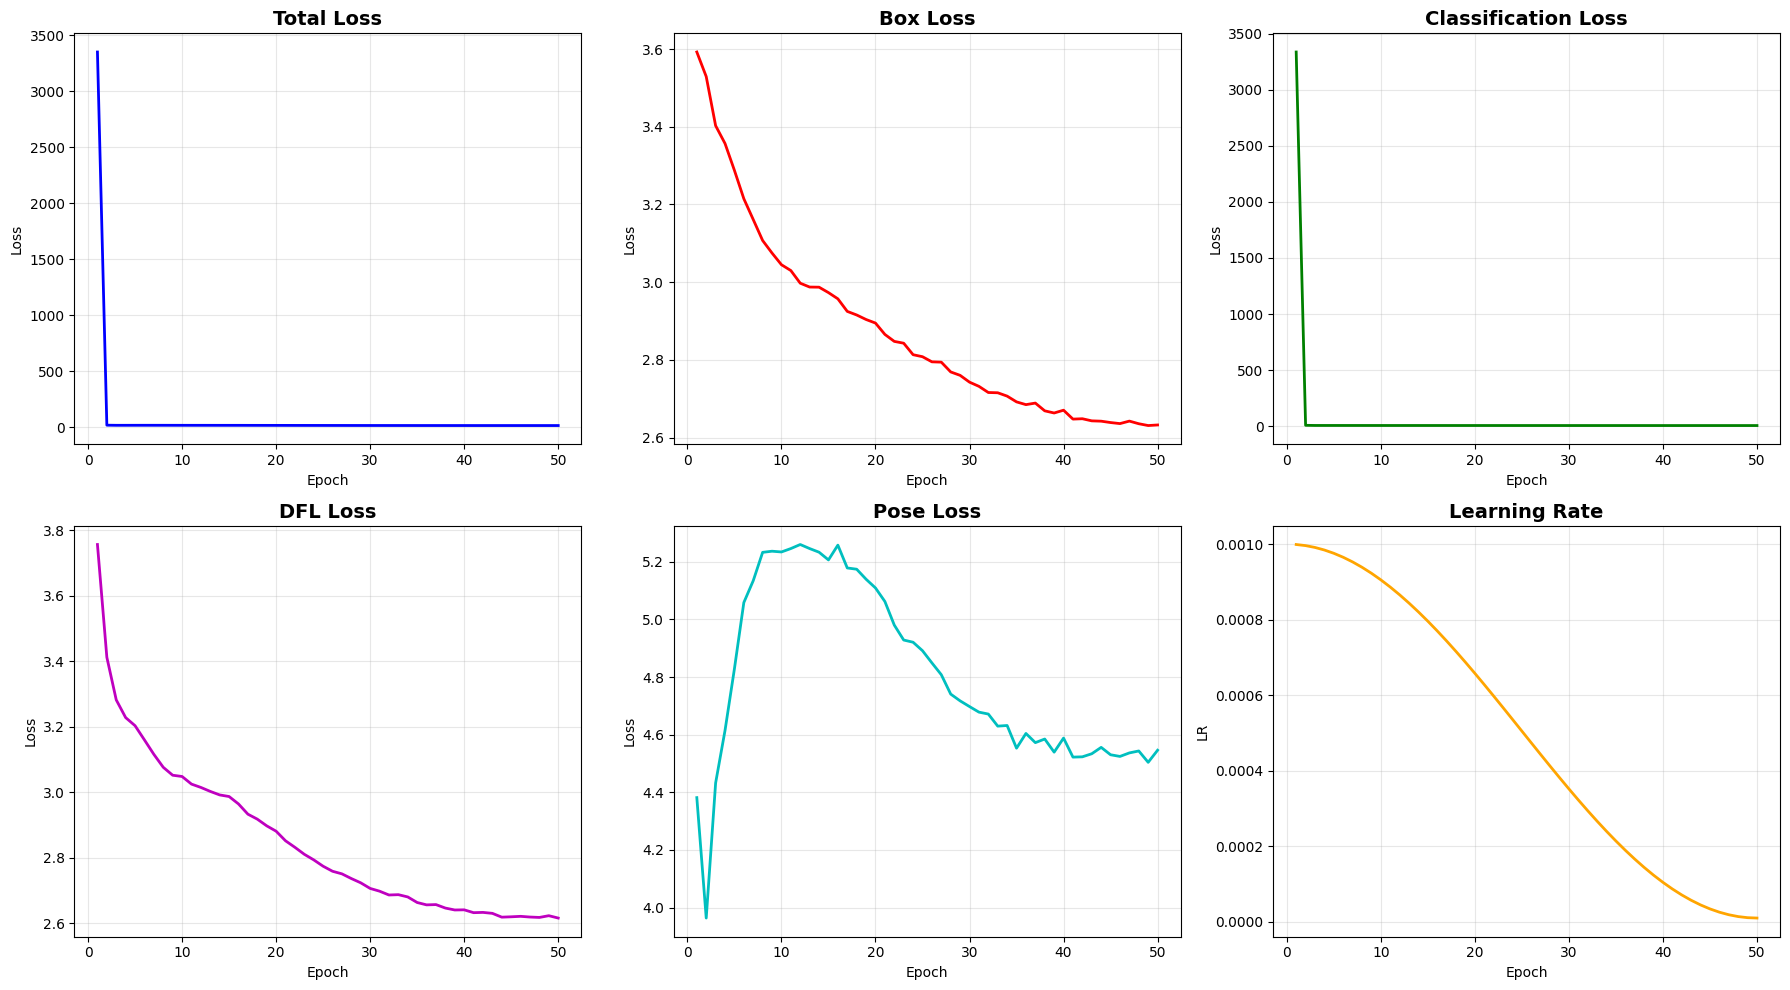

Training curves saved to: outputs/results/training_curves.png


In [37]:
# Plot training curves
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Total loss
axes[0, 0].plot(history['epoch'], history['total_loss'], 'b-', linewidth=2)
axes[0, 0].set_title('Total Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True, alpha=0.3)

# Box loss
axes[0, 1].plot(history['epoch'], history['box_loss'], 'r-', linewidth=2)
axes[0, 1].set_title('Box Loss', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].grid(True, alpha=0.3)

# Class loss
axes[0, 2].plot(history['epoch'], history['cls_loss'], 'g-', linewidth=2)
axes[0, 2].set_title('Classification Loss', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Loss')
axes[0, 2].grid(True, alpha=0.3)

# DFL loss
axes[1, 0].plot(history['epoch'], history['dfl_loss'], 'm-', linewidth=2)
axes[1, 0].set_title('DFL Loss', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].grid(True, alpha=0.3)

# Pose loss
axes[1, 1].plot(history['epoch'], history['pose_loss'], 'c-', linewidth=2)
axes[1, 1].set_title('Pose Loss', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].grid(True, alpha=0.3)

# Learning rate
axes[1, 2].plot(history['epoch'], history['lr'], 'orange', linewidth=2)
axes[1, 2].set_title('Learning Rate', fontsize=14, fontweight='bold')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('LR')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs('outputs/results', exist_ok=True)
plt.savefig('outputs/results/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("Training curves saved to: outputs/results/training_curves.png")


## 9. Test Inference on Sample Images

Found 0 high-confidence detections (threshold: 0.1)


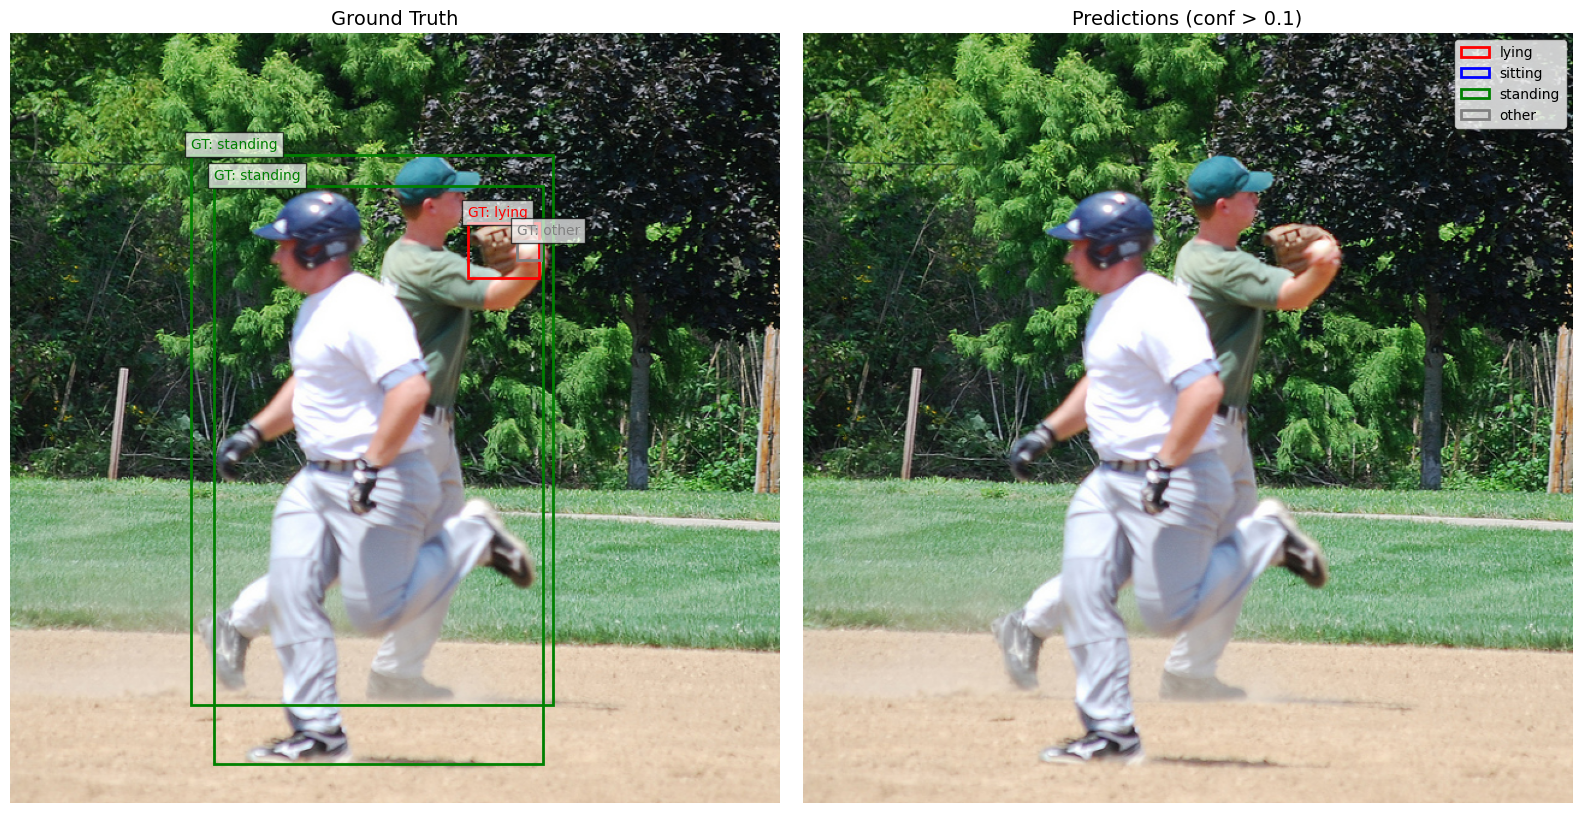

Ground truth boxes: 4
Predicted boxes: 0
Visualization saved to: outputs/visualizations/inference_example.png


In [41]:
# Load the trained model for inference
model_pose.eval()

# Get a test image
image_idx = 3
test_img_tensor, test_labels = ovad_dataset[image_idx]

# Convert to display format
test_img_display = test_img_tensor.numpy().transpose(1, 2, 0).astype(np.uint8)

# Run inference
test_img_batch = test_img_tensor.unsqueeze(0).float().to(device)
with torch.no_grad():
    predictions = model_pose(test_img_batch)

# Extract predictions
pred_boxes = predictions[0, :4, :].cpu()
pred_class_scores = predictions[0, 4:84, :].cpu()
pred_pose_scores = predictions[0, 84:87, :].cpu()

# Filter for high-confidence person detections
person_class_id = 0
confidence_threshold = val_config.CONF_THRESHOLD
person_scores = pred_class_scores[person_class_id, :]

high_conf_mask = person_scores > confidence_threshold
filtered_boxes = pred_boxes[:, high_conf_mask]
filtered_poses = pred_pose_scores[:, high_conf_mask].argmax(dim=0)
filtered_scores = person_scores[high_conf_mask]

print(f"Found {filtered_boxes.shape[1]} high-confidence detections (threshold: {confidence_threshold})")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

pose_names = model_config.POSE_CLASSES
pose_colors = ['red', 'blue', 'green', 'gray'] # Added 'gray' for 'other' class

# Ground truth
ax1.imshow(test_img_display)
ax1.set_title('Ground Truth', fontsize=14)
ax1.axis('off')

if len(test_labels) > 0:
    for i in range(test_labels.shape[0]):
        x_c, y_c, w, h = test_labels[i, 1:5].numpy()
        pose_id = int(test_labels[i, 5].item())

        x_c *= model_config.INPUT_SIZE
        y_c *= model_config.INPUT_SIZE
        w *= model_config.INPUT_SIZE
        h *= model_config.INPUT_SIZE

        x1 = x_c - w/2
        y1 = y_c - h/2

        rect = patches.Rectangle((x1, y1), w, h, linewidth=2,
                                edgecolor=pose_colors[pose_id], facecolor='none')
        ax1.add_patch(rect)
        ax1.text(x1, y1-5, f'GT: {pose_names[pose_id]}',
                color=pose_colors[pose_id], fontsize=10,
                bbox=dict(facecolor='white', alpha=0.7))

# Predictions
ax2.imshow(test_img_display)
ax2.set_title(f'Predictions (conf > {confidence_threshold})', fontsize=14)
ax2.axis('off')

for i in range(filtered_boxes.shape[1]):
    x_c_pred, y_c_pred, w_pred, h_pred = filtered_boxes[:, i].numpy()
    pose_id = int(filtered_poses[i].item())
    score = filtered_scores[i].item()

    x1_pred = x_c_pred - w_pred/2
    y1_pred = y_c_pred - h_pred/2

    rect = patches.Rectangle((x1_pred, y1_pred), w_pred, h_pred, linewidth=2,
                            edgecolor=pose_colors[pose_id], facecolor='none')
    ax2.add_patch(rect)
    ax2.text(x1_pred, y1_pred-5, f'{pose_names[pose_id]}: {score:.2f}',
            color=pose_colors[pose_id], fontsize=10,
            bbox=dict(facecolor='white', alpha=0.7))

# Add legend
legend_elements = [patches.Patch(facecolor='none', edgecolor=pose_colors[i],
                        label=pose_names[i], linewidth=2) for i in range(len(pose_names))]
ax2.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
os.makedirs('outputs/visualizations', exist_ok=True)
plt.savefig('outputs/visualizations/inference_example.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Ground truth boxes: {test_labels.shape[0] if len(test_labels) > 0 else 0}")
print(f"Predicted boxes: {filtered_boxes.shape[1]}")
print(f"Visualization saved to: outputs/visualizations/inference_example.png")

## 10. Download Trained Model

Download the trained model and training curves to your local machine

In [42]:
# Zip all outputs (checkpoints, results, visualizations)
!zip -r trained_model.zip outputs/

# Download to local machine
from google.colab import files
files.download('trained_model.zip')

print("Model and results ready for download!")


  adding: outputs/ (stored 0%)
  adding: outputs/results/ (stored 0%)
  adding: outputs/results/training_curves.png (deflated 14%)
  adding: outputs/checkpoints/ (stored 0%)
  adding: outputs/checkpoints/yolov8n_pose_epoch_45.pt (deflated 8%)
  adding: outputs/checkpoints/yolov8n_pose_epoch_35.pt (deflated 8%)
  adding: outputs/checkpoints/yolov8n_pose_epoch_15.pt (deflated 8%)
  adding: outputs/checkpoints/yolov8n_pose_epoch_25.pt (deflated 8%)
  adding: outputs/checkpoints/yolov8n_pose_epoch_20.pt (deflated 8%)
  adding: outputs/checkpoints/yolov8n_pose_epoch_50.pt (deflated 8%)
  adding: outputs/checkpoints/yolov8n_pose_epoch_10.pt (deflated 9%)
  adding: outputs/checkpoints/yolov8n_pose_epoch_40.pt (deflated 8%)
  adding: outputs/checkpoints/yolov8n_pose_epoch_30.pt (deflated 8%)
  adding: outputs/checkpoints/yolov8n_pose_epoch_5.pt (deflated 8%)
  adding: outputs/logs/ (stored 0%)
  adding: outputs/visualizations/ (stored 0%)
  adding: outputs/visualizations/inference_example.png 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model and results ready for download!
